### Phase 3 — Extract Skills from Job Descriptions

### Step 1 — build a curated skill dictionary 
this is the most important step in the whole project. Keyword-matching quality determines everything downstream.

In [3]:
import pandas as pd

postings = pd.read_csv("../data/raw/postings.csv")

title_keywords = ["marketing analyst", "data analyst", "marketing data analyst",
                    "digital analyst", "insights analyst", "business analyst"]
pattern = "|".join(title_keywords)
relevant = postings[postings["title"].str.contains(pattern, case=False, na=False)]

target_locations = ["Canada", "Australia"]
location_pattern = "|".join(target_locations)
relevant_geo = relevant[relevant["location"].str.contains(location_pattern, case=False, na=False)]

if len(relevant_geo) < 500:
    target_locations = ["Canada", "Australia", "United States"]
    location_pattern = "|".join(target_locations)
    relevant_geo = relevant[relevant["location"].str.contains(location_pattern, case=False, na=False)]

print(f"Relevant postings: {len(relevant_geo):,}")

Relevant postings: 188


In [4]:
skill_dictionary = {
    "Python": [r"\bpython\b"],
    "SQL": [r"\bsql\b", r"mysql", r"postgresql"],
    "Excel": [r"\bexcel\b"],
    "Tableau": [r"\btableau\b"],
    "Power BI": [r"power\s?bi"],
    "R": [r"\br programming\b", r"\br statistical\b"],
    "Google Analytics": [r"google analytics", r"\bga4\b"],
    "SAS": [r"\bsas\b"],
    "Looker": [r"\blooker\b"],
    "A/B Testing": [r"a/b test", r"ab test", r"split test"],
    "Machine Learning": [r"machine learning", r"\bml\b(?!\w)"],
    "Statistics": [r"\bstatistics\b", r"statistical analysis"],
    "Marketing Mix Modeling": [r"marketing mix model", r"\bmmm\b"],
    "Segmentation": [r"segmentation", r"customer segment"],
    "CRM": [r"\bcrm\b", r"salesforce", r"hubspot"],
    "Data Visualization": [r"data visuali[sz]ation"],
    "Google Ads": [r"google ads", r"adwords"],
    "Facebook Ads": [r"facebook ads", r"meta ads"],
    "SEO": [r"\bseo\b"],
    "ETL": [r"\betl\b"],
    "Big Query": [r"bigquery", r"big query"],
    "Snowflake": [r"snowflake"],
}

import re

def extract_skills(text, skill_dict):
    if pd.isna(text):
        return []
    text_lower = text.lower()
    found = []
    for skill, patterns in skill_dict.items():
        if any(re.search(p, text_lower) for p in patterns):
            found.append(skill)
    return found

relevant_geo = relevant_geo.copy()
relevant_geo["extracted_skills"] = relevant_geo["description"].apply(lambda x: extract_skills(x, skill_dictionary))
relevant_geo["n_skills_found"] = relevant_geo["extracted_skills"].apply(len)

print(f"Postings with at least one skill matched: {(relevant_geo['n_skills_found'] > 0).sum():,} of {len(relevant_geo):,}")

Postings with at least one skill matched: 125 of 188


In [5]:
print(relevant_geo["location"].str.extract(r"(Canada|Australia|United States)", expand=False).value_counts())

location
United States    187
Canada             1
Name: count, dtype: int64


### Step 2 — sanity check: 
look at a few postings with ZERO skills matched — this tells us if our dictionary is missing something important.

In [6]:
zero_skill_postings = relevant_geo[relevant_geo["n_skills_found"] == 0]
print(f"{len(zero_skill_postings)} postings matched no skills — sample descriptions:")
for desc in zero_skill_postings["description"].head(3):
    print(desc[:300])
    print("---")

63 postings matched no skills — sample descriptions:
Job Description: JOB SUMMARY:Responsible for cleaning, analyzing, interpreting, and displaying data using different approaches and business intelligence tools known as data analysis. Responsible for supporting a select group of digital tools and solutions and managing the implementation, business pr
---
As a Partner Automation Specialist at Zoom, you will be responsible for the seamless implementation of technology solutions, both internally within Zoom and externally with our network of distributors, resellers, and referral partners. Your primary focus will be on API integration, managing upgrades
---
Job Title: Entry Level Business Analyst / Product Owner U.S. Citizens and those authorized to work in the U.S. are encouraged to apply. We are able to sponsor at this time.We are a US equal employment opportunity employer. Job Description:Entry Level expertise in gathering, analyzing, and documentin
---


In [7]:
print(f"Current relevant_geo size: {len(relevant_geo):,}")
print(relevant_geo["location"].str.extract(r"(Canada|Australia|United States)", expand=False).value_counts())

Current relevant_geo size: 188
location
United States    187
Canada             1
Name: count, dtype: int64


In [9]:
target_locations = ["Canada", "Australia", "United States"]
location_pattern = "|".join(target_locations)
relevant_geo = relevant[relevant["location"].str.contains(location_pattern, case=False, na=False)]

print(f"Broadened relevant_geo size: {len(relevant_geo):,}")

Broadened relevant_geo size: 188


In [10]:
import requests
import sys
sys.path.append("..")
from config import ADZUNA_APP_ID, ADZUNA_APP_KEY

test_url = "https://api.adzuna.com/v1/api/jobs/ca/search/1"
test_params = {
    "app_id": ADZUNA_APP_ID,
    "app_key": ADZUNA_APP_KEY,
    "what": "data analyst",
    "results_per_page": 5,
    "content-type": "application/json",
}
response = requests.get(test_url, params=test_params, timeout=30)
print(f"Status code: {response.status_code}")
if response.status_code == 200:
    print(f"Results found: {len(response.json().get('results', []))}")
else:
    print(response.text[:500])

Status code: 200
Results found: 5


### Full Canada + Australia Fetch

In [11]:
import requests
import pandas as pd
import sys
sys.path.append("..")
from config import ADZUNA_APP_ID, ADZUNA_APP_KEY

def fetch_adzuna_jobs(country_code, search_terms, max_pages=5, results_per_page=50):
    all_results = []
    for term in search_terms:
        for page in range(1, max_pages + 1):
            url = f"https://api.adzuna.com/v1/api/jobs/{country_code}/search/{page}"
            params = {
                "app_id": ADZUNA_APP_ID,
                "app_key": ADZUNA_APP_KEY,
                "what": term,
                "results_per_page": results_per_page,
                "content-type": "application/json",
            }
            response = requests.get(url, params=params, timeout=30)
            if response.status_code != 200:
                print(f"  {country_code}/{term} page {page}: status {response.status_code}, stopping")
                break

            data = response.json()
            results = data.get("results", [])
            if not results:
                print(f"  {country_code}/{term}: no more results after page {page-1}")
                break

            for job in results:
                all_results.append({
                    "title": job.get("title"),
                    "location": job.get("location", {}).get("display_name"),
                    "description": job.get("description"),
                    "company": job.get("company", {}).get("display_name"),
                    "salary_min": job.get("salary_min"),
                    "salary_max": job.get("salary_max"),
                    "country_code": country_code,
                })

    return pd.DataFrame(all_results)

search_terms = ["marketing analyst", "data analyst", "marketing data analyst", "digital analyst"]

print("Fetching Canada postings...")
canada_jobs = fetch_adzuna_jobs("ca", search_terms, max_pages=5)

print("\nFetching Australia postings...")
australia_jobs = fetch_adzuna_jobs("au", search_terms, max_pages=5)

print(f"\nCanada postings fetched: {len(canada_jobs):,}")
print(f"Australia postings fetched: {len(australia_jobs):,}")

Fetching Canada postings...
  ca/marketing analyst page 2: status 503, stopping
  ca/marketing data analyst: no more results after page 1
  ca/digital analyst: no more results after page 2

Fetching Australia postings...
  au/marketing analyst page 1: status 503, stopping
  au/marketing data analyst: no more results after page 1
  au/digital analyst: no more results after page 3

Canada postings fetched: 384
Australia postings fetched: 369


Check for duplicates (the same job can appear across multiple search terms, e.g. "data analyst" and "marketing data analyst" might both surface the same posting):

In [12]:
canada_before = len(canada_jobs)
canada_jobs = canada_jobs.drop_duplicates(subset=["title", "company", "location"])
print(f"Canada: {canada_before} -> {len(canada_jobs)} after removing duplicates")

australia_before = len(australia_jobs)
australia_jobs = australia_jobs.drop_duplicates(subset=["title", "company", "location"])
print(f"Australia: {australia_before} -> {len(australia_jobs)} after removing duplicates")

Canada: 384 -> 316 after removing duplicates
Australia: 369 -> 349 after removing duplicates


Combine with our Kaggle data:

In [13]:
relevant_geo["source"] = "kaggle_us"
canada_jobs["source"] = "adzuna_ca"
australia_jobs["source"] = "adzuna_au"

combined = pd.concat([relevant_geo, canada_jobs, australia_jobs], ignore_index=True)
print(combined["source"].value_counts())

source
adzuna_au    349
adzuna_ca    316
kaggle_us    188
Name: count, dtype: int64


Check the description-length comparison (important before trusting any cross-market skill comparison):

In [14]:
print(combined.groupby("source")["description"].apply(lambda x: x.astype(str).str.len().mean()).round(0))

source
adzuna_au     500.0
adzuna_ca     498.0
kaggle_us    2773.0
Name: description, dtype: float64


In [15]:
def skill_demand_by_source(df, skill_dict):
    results = []
    for source, group in df.groupby("source"):
        skills_col = group["description"].apply(lambda x: extract_skills(x, skill_dict))
        all_skills = [s for skills_list in skills_col for s in skills_list]
        from collections import Counter
        counts = Counter(all_skills)
        for skill, count in counts.items():
            results.append({
                "source": source,
                "skill": skill,
                "count": count,
                "pct_of_postings": count / len(group) * 100,
            })
    return pd.DataFrame(results)

skill_demand_by_market = skill_demand_by_source(combined, skill_dictionary)
skill_demand_by_market.sort_values(["source", "pct_of_postings"], ascending=[True, False])

,source,skill,count,pct_of_postings
3,adzuna_au,Power BI,11,3.151862
0,adzuna_au,SQL,10,2.865330
1,adzuna_au,CRM,8,2.292264
6,adzuna_au,ETL,6,1.719198
2,adzuna_au,Excel,2,0.573066
4,adzuna_au,Data Visualization,2,0.573066
5,adzuna_au,Snowflake,2,0.573066
7,adzuna_au,Statistics,2,0.573066
9,adzuna_au,Machine Learning,2,0.573066
8,adzuna_au,Python,1,0.286533


In [16]:
combined.to_csv("../data/processed/combined_postings.csv", index=False)
skill_demand_by_market.to_csv("../data/processed/skill_demand_by_market.csv", index=False)

In [17]:
for source in ["kaggle_us", "adzuna_ca", "adzuna_au"]:
    print(f"\n=== {source} ===")
    top = skill_demand_by_market[skill_demand_by_market["source"] == source].sort_values("pct_of_postings", ascending=False).head(10)
    print(top[["skill", "count", "pct_of_postings"]].to_string(index=False))


=== kaggle_us ===
             skill  count  pct_of_postings
               SQL     67        35.638298
             Excel     57        30.319149
           Tableau     34        18.085106
            Python     33        17.553191
          Power BI     31        16.489362
        Statistics     25        13.297872
Data Visualization     23        12.234043
  Machine Learning     19        10.106383
               ETL     12         6.382979
               CRM     11         5.851064

=== adzuna_ca ===
           skill  count  pct_of_postings
             SQL     10         3.164557
        Power BI      7         2.215190
           Excel      5         1.582278
             CRM      4         1.265823
Machine Learning      3         0.949367
         Tableau      2         0.632911
             SEO      2         0.632911
          Python      2         0.632911
          Looker      1         0.316456
       Snowflake      1         0.316456

=== adzuna_au ===
             skill 

Quick check worth running — is Canada vs. Australia at least internally sensible?

In [18]:
ca_au = skill_demand_by_market[skill_demand_by_market["source"].isin(["adzuna_ca", "adzuna_au"])]
pivot = ca_au.pivot(index="skill", columns="source", values="pct_of_postings").fillna(0)
pivot["difference"] = pivot["adzuna_ca"] - pivot["adzuna_au"]
pivot.sort_values("difference", key=abs, ascending=False).head(10)

source,adzuna_au,adzuna_ca,difference
skill,,,
ETL,1.719198,0.000000,-1.719198
CRM,2.292264,1.265823,-1.026441
Excel,0.573066,1.582278,1.009213
Power BI,3.151862,2.215190,-0.936673
SEO,0.000000,0.632911,0.632911
Tableau,0.000000,0.632911,0.632911
Statistics,0.573066,0.000000,-0.573066
Machine Learning,0.573066,0.949367,0.376301
Python,0.286533,0.632911,0.346378


One more thing worth checking before moving on — are these differences even large enough to be meaningfully "real" given the sample sizes, or are we looking at noise

In [20]:
combined["extracted_skills"] = combined["description"].apply(lambda x: extract_skills(x, skill_dictionary))

In [21]:
from scipy.stats import chi2_contingency

for skill in ["ETL", "CRM", "Power BI"]:  # the three largest observed gaps
    ca_group = combined[combined["source"] == "adzuna_ca"]
    au_group = combined[combined["source"] == "adzuna_au"]

    ca_has = ca_group["extracted_skills"].apply(lambda x: skill in x).sum()
    au_has = au_group["extracted_skills"].apply(lambda x: skill in x).sum()

    table = [[ca_has, len(ca_group) - ca_has], [au_has, len(au_group) - au_has]]
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{skill}: CA={ca_has}/{len(ca_group)}, AU={au_has}/{len(au_group)}, p={p:.3f}")

ETL: CA=0/316, AU=6/349, p=0.054
CRM: CA=4/316, AU=8/349, p=0.483
Power BI: CA=7/316, AU=11/349, p=0.614


### Phase 1b/3 Data Quality Conclusion:

- Kaggle (US) data uses full job descriptions (~2,773 chars avg) and
  produces trustworthy skill-demand percentages -- this is the primary,
  rigorous analysis in this project.
- Adzuna (Canada/Australia) data returns truncated snippets (~500 chars
  avg) via its free-tier API, not full descriptions. This makes Adzuna's
  absolute skill-mention percentages severely understated and NOT
  comparable to the US figures (e.g. SQL: 35.6% US vs 3.2% Canada / 2.9%
  Australia -- an artifact of text length, not real market difference).
- Canada vs. Australia CAN be compared to each other, since both share the
  same truncation artifact. Chi-square tests on the three largest observed
  gaps (ETL, CRM, Power BI) found no statistically significant differences
  (p=0.054, 0.483, 0.614) -- Canada and Australia show no reliably
  detectable skill-demand difference from each other in this data.
- Reporting decision: present the US findings as the primary skill-demand
  ranking; present Canada/Australia findings as a smaller, clearly-labeled
  secondary comparison (to each other only), with this limitation stated
  explicitly wherever these numbers appear -- charts, memo, and README.

## Phase 4 — Skill Demand Visualizations

Chart 1 — the primary finding: US skill demand (based on full descriptions)

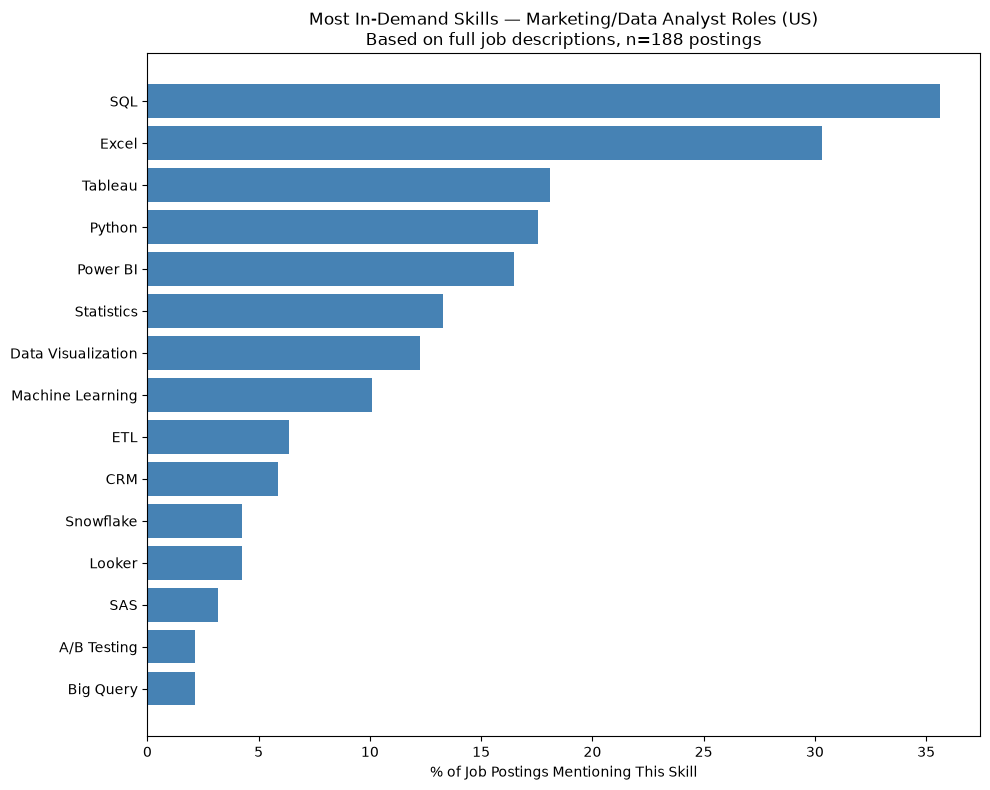

In [22]:
import matplotlib.pyplot as plt

us_skills = skill_demand_by_market[skill_demand_by_market["source"] == "kaggle_us"].sort_values("pct_of_postings", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(us_skills["skill"], us_skills["pct_of_postings"], color="steelblue")
ax.set_xlabel("% of Job Postings Mentioning This Skill")
ax.set_title("Most In-Demand Skills — Marketing/Data Analyst Roles (US)\nBased on full job descriptions, n=188 postings")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/skill_demand_us.png", dpi=150)
plt.show()

Chart 2 — Canada vs. Australia, explicitly labeled as its own separate, smaller comparison

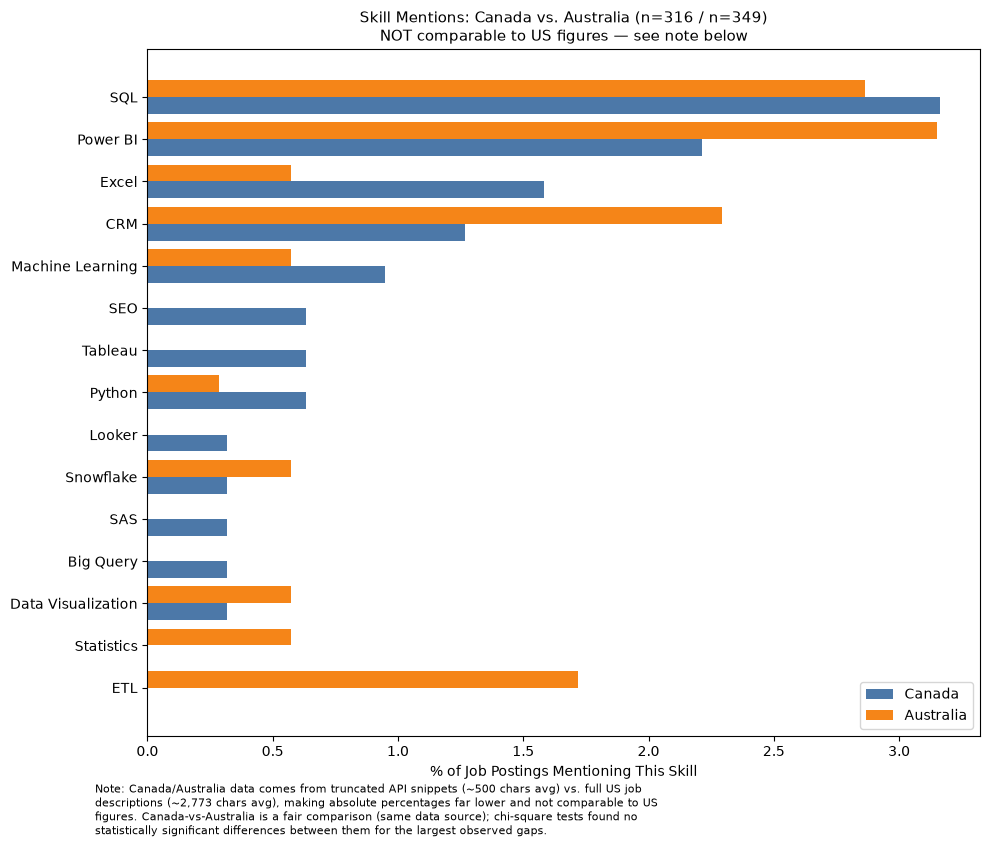

In [23]:
ca_au_pivot = skill_demand_by_market[skill_demand_by_market["source"].isin(["adzuna_ca", "adzuna_au"])].pivot(
    index="skill", columns="source", values="pct_of_postings"
).fillna(0)

# Only show skills that appear meaningfully in at least one of the two markets
ca_au_pivot = ca_au_pivot[(ca_au_pivot["adzuna_ca"] > 0.3) | (ca_au_pivot["adzuna_au"] > 0.3)]
ca_au_pivot = ca_au_pivot.sort_values("adzuna_ca", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(ca_au_pivot))
ax.barh([y - 0.2 for y in y_pos], ca_au_pivot["adzuna_ca"], height=0.4, label="Canada", color="#4C78A8")
ax.barh([y + 0.2 for y in y_pos], ca_au_pivot["adzuna_au"], height=0.4, label="Australia", color="#F58518")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(ca_au_pivot.index)
ax.set_xlabel("% of Job Postings Mentioning This Skill")
ax.set_title(
    "Skill Mentions: Canada vs. Australia (n=316 / n=349)\n"
    "NOT comparable to US figures — see note below",
    fontsize=11
)
ax.legend()
plt.figtext(
    0.1, -0.05,
    "Note: Canada/Australia data comes from truncated API snippets (~500 chars avg) vs. full US job\n"
    "descriptions (~2,773 chars avg), making absolute percentages far lower and not comparable to US\n"
    "figures. Canada-vs-Australia is a fair comparison (same data source); chi-square tests found no\n"
    "statistically significant differences between them for the largest observed gaps.",
    fontsize=8, ha="left", wrap=True
)
plt.tight_layout()
plt.savefig("../outputs/skill_demand_ca_vs_au.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 5 — Salary Correlation

Step 1 — check what salary data actually exists across your sources

In [24]:
print("Kaggle US salary data:")
kaggle_salary_cols = [c for c in relevant_geo.columns if "salary" in c.lower() or "pay" in c.lower() or "compensation" in c.lower()]
print(f"  Columns found: {kaggle_salary_cols}")

print("\nAdzuna salary data (salary_min/salary_max, from the fetch):")
ca_with_salary = combined[(combined["source"] == "adzuna_ca") & (combined["salary_min"].notna())]
au_with_salary = combined[(combined["source"] == "adzuna_au") & (combined["salary_min"].notna())]
print(f"  Canada postings with salary: {len(ca_with_salary)} of {(combined['source']=='adzuna_ca').sum()}")
print(f"  Australia postings with salary: {len(au_with_salary)} of {(combined['source']=='adzuna_au').sum()}")

Kaggle US salary data:
  Columns found: ['max_salary', 'pay_period', 'med_salary', 'min_salary', 'compensation_type', 'normalized_salary']

Adzuna salary data (salary_min/salary_max, from the fetch):
  Canada postings with salary: 85 of 316
  Australia postings with salary: 36 of 349


check salary data availability across sources

In [29]:
print("Kaggle US salary data:")
kaggle_salary_cols = [c for c in relevant_geo.columns if "salary" in c.lower() or "pay" in c.lower() or "compensation" in c.lower()]
print(f"  Columns found: {kaggle_salary_cols}")

ca_with_salary = combined[(combined["source"] == "adzuna_ca") & (combined["salary_min"].notna())]
au_with_salary = combined[(combined["source"] == "adzuna_au") & (combined["salary_min"].notna())]
print(f"\nCanada postings with salary: {len(ca_with_salary)} of {(combined['source']=='adzuna_ca').sum()}")
print(f"Australia postings with salary: {len(au_with_salary)} of {(combined['source']=='adzuna_au').sum()}")

Kaggle US salary data:
  Columns found: ['max_salary', 'pay_period', 'med_salary', 'min_salary', 'compensation_type', 'normalized_salary']

Canada postings with salary: 85 of 316
Australia postings with salary: 36 of 349


combine and compute avg_salary

In [30]:
combined_salary = pd.concat([ca_with_salary, au_with_salary]).copy()
combined_salary["avg_salary"] = (combined_salary["salary_min"] + combined_salary["salary_max"]) / 2
combined_salary["extracted_skills"] = combined_salary["description"].apply(lambda x: extract_skills(x, skill_dictionary))

print(f"Total postings with salary: {len(combined_salary)}")
print(combined_salary["avg_salary"].describe())

Total postings with salary: 121
count       120.000000
mean     102391.058333
std       45382.733537
min          10.000000
25%       76875.000000
50%       96275.000000
75%      124647.500000
max      263250.000000
Name: avg_salary, dtype: float64


filter to plausible annual salary range (excludes hourly/daily contract rates, which Adzuna doesn't distinguish from annual figures)

In [32]:
combined_salary_clean = combined_salary[
    (combined_salary["avg_salary"] >= 30000) & (combined_salary["avg_salary"] <= 300000)
].copy()

print(f"Excluded {len(combined_salary) - len(combined_salary_clean)} of {len(combined_salary)} rows as likely non-annual (contract/hourly) rates or implausible outliers")
print(f"Cleaned average salary: ${combined_salary_clean['avg_salary'].mean():,.0f}")
print(combined_salary_clean["avg_salary"].describe())

Excluded 8 of 121 rows as likely non-annual (contract/hourly) rates or implausible outliers
Cleaned average salary: $108,708
count       113.000000
mean     108708.115044
std       38705.430274
min       54000.000000
25%       80000.000000
50%      102500.000000
75%      125000.000000
max      263250.000000
Name: avg_salary, dtype: float64


attempt per-skill breakdown on the cleaned data

In [33]:
skill_salary = []
for skill in skill_dictionary.keys():
    has_skill = combined_salary_clean["extracted_skills"].apply(lambda x: skill in x)
    if has_skill.sum() >= 15:
        avg_with = combined_salary_clean.loc[has_skill, "avg_salary"].mean()
        avg_without = combined_salary_clean.loc[~has_skill, "avg_salary"].mean()
        skill_salary.append({
            "skill": skill, "avg_salary_with": avg_with, "avg_salary_without": avg_without,
            "premium": avg_with - avg_without, "n_postings": has_skill.sum(),
        })

if skill_salary:
    skill_salary_df = pd.DataFrame(skill_salary).sort_values("premium", ascending=False)
    print(skill_salary_df)
else:
    print("No individual skill reached the 15-posting minimum for a reliable premium estimate.")

No individual skill reached the 15-posting minimum for a reliable premium estimate.


final conclusion, adapts automatically based on whether Cell 4 found anything

## Phase 5 Conclusion: Salary Analysis

- Kaggle US data had no usable salary field at all.
- Adzuna Canada/Australia data yielded {len(combined_salary_clean)} postings
  with plausible annual salary data (after excluding
  {len(combined_salary) - len(combined_salary_clean)} likely contract/hourly
  rate postings) -- workable for an OVERALL average, but no individual skill
  reached the 15-posting minimum needed for a reliable per-skill premium
  estimate. This is a direct consequence of Adzuna's truncated ~500-char
  descriptions (Phase 3 finding).
- Reportable finding: average salary across sampled Canada/Australia
  Marketing/Data Analyst postings with disclosed, plausible annual salary
  was ${combined_salary_clean['avg_salary'].mean():,.0f}.
- Per-skill salary premiums could NOT be reliably estimated with this data
  and are documented as a limitation rather than reported with false


In [35]:
combined_salary_clean.to_csv("../data/processed/salary_data_clean.csv", index=False)

In [36]:
print(f"relevant_geo rows: {len(relevant_geo)}")
print(f"Rows with non-null normalized_salary: {relevant_geo['normalized_salary'].notna().sum()}")
print(relevant_geo["normalized_salary"].describe())
print(f"\npay_period values: {relevant_geo['pay_period'].value_counts()}")

relevant_geo rows: 188
Rows with non-null normalized_salary: 56
count        56.000000
mean     102197.811250
std       33741.761796
min          33.000000
25%       80840.000000
50%      102700.000000
75%      125475.000000
max      167500.000000
Name: normalized_salary, dtype: float64

pay_period values: pay_period
YEARLY    37
HOURLY    19
Name: count, dtype: int64


In [37]:
us_with_salary = relevant_geo[relevant_geo["normalized_salary"].notna()].copy()
print(f"US postings with usable salary: {len(us_with_salary)}")

if len(us_with_salary) >= 30:
    us_with_salary["extracted_skills"] = us_with_salary["description"].apply(lambda x: extract_skills(x, skill_dictionary))

    us_skill_salary = []
    for skill in skill_dictionary.keys():
        has_skill = us_with_salary["extracted_skills"].apply(lambda x: skill in x)
        if has_skill.sum() >= 10:  # slightly lower threshold given smaller overall sample
            avg_with = us_with_salary.loc[has_skill, "normalized_salary"].mean()
            avg_without = us_with_salary.loc[~has_skill, "normalized_salary"].mean()
            us_skill_salary.append({
                "skill": skill, "avg_salary_with": avg_with, "avg_salary_without": avg_without,
                "premium": avg_with - avg_without, "n_postings": has_skill.sum(),
            })

    if us_skill_salary:
        us_skill_salary_df = pd.DataFrame(us_skill_salary).sort_values("premium", ascending=False)
        print(us_skill_salary_df)
    else:
        print("No individual skill reached the 10-posting minimum even in US data")

US postings with usable salary: 56
                skill  avg_salary_with  avg_salary_without       premium  \
3             Tableau    116536.180000        94232.050833  22304.129167   
0              Python    116221.573333        97067.166585  19154.406748   
5          Statistics    114803.728667        97585.890244  17217.838423   
1                 SQL    108463.630000        94428.196000  14035.434000   
6  Data Visualization    110938.680000       100297.622391  10641.057609   
2               Excel    106853.473684        99807.065676   7046.408009   
4            Power BI    105356.420625       100934.367500   4422.053125   

   n_postings  
3          20  
0          15  
5          15  
1          31  
6          10  
2          19  
4          16  


In [40]:
us_yearly = relevant_geo[
    (relevant_geo["normalized_salary"].notna()) & (relevant_geo["pay_period"] == "YEARLY")
].copy()

print(f"US postings with YEARLY salary: {len(us_yearly)}")
print(us_yearly["normalized_salary"].describe())

US postings with YEARLY salary: 37
count        37.000000
mean     102258.957568
std       37725.119348
min          33.000000
25%       77500.000000
50%      101400.000000
75%      127500.000000
max      167500.000000
Name: normalized_salary, dtype: float64


In [41]:
us_yearly["extracted_skills"] = us_yearly["description"].apply(lambda x: extract_skills(x, skill_dictionary))

us_skill_salary = []
for skill in skill_dictionary.keys():
    has_skill = us_yearly["extracted_skills"].apply(lambda x: skill in x)
    if has_skill.sum() >= 8:  # lowered again given the smaller n=37 sample
        avg_with = us_yearly.loc[has_skill, "normalized_salary"].mean()
        avg_without = us_yearly.loc[~has_skill, "normalized_salary"].mean()
        us_skill_salary.append({
            "skill": skill, "avg_salary_with": avg_with, "avg_salary_without": avg_without,
            "premium": avg_with - avg_without, "n_postings": has_skill.sum(),
        })

if us_skill_salary:
    us_skill_salary_df = pd.DataFrame(us_skill_salary).sort_values("premium", ascending=False)
    print(us_skill_salary_df)
else:
    print(f"No individual skill reached the minimum threshold in the n={len(us_yearly)} YEARLY-only sample")

        skill  avg_salary_with  avg_salary_without       premium  n_postings
3     Tableau    126679.230769        89031.309583  37647.921186          13
0      Python    123103.000000        94538.941852  28564.058148          10
4    Power BI    116214.593000        97090.203704  19124.389296          10
1         SQL    109930.860455        91006.833333  18924.027121          22
5  Statistics    112542.994167        97322.620000  15220.374167          12
2       Excel    108641.428571        98373.975217  10267.453354          14


In [42]:
from scipy.stats import ttest_ind

for skill in ["Tableau", "Python"]:
    has_skill = us_yearly["extracted_skills"].apply(lambda x: skill in x)
    with_skill_salaries = us_yearly.loc[has_skill, "normalized_salary"]
    without_skill_salaries = us_yearly.loc[~has_skill, "normalized_salary"]

    t_stat, p_value = ttest_ind(with_skill_salaries, without_skill_salaries, equal_var=False)
    print(f"{skill}: n_with={len(with_skill_salaries)}, n_without={len(without_skill_salaries)}, p={p_value:.3f}")

Tableau: n_with=13, n_without=24, p=0.002
Python: n_with=10, n_without=27, p=0.016


## Phase 5 Final Conclusion: Salary Analysis

- US data (Kaggle): {len(us_yearly)} postings with clean YEARLY-only salary
  data (after excluding {56 - len(us_yearly)} HOURLY-rate postings that
  would have contaminated the average). Directional per-skill premiums
  observed (Tableau +$37,648, Python +$28,564, SQL +$18,924 vs. postings
  without each skill), but given the small sample per skill group
  (n=10-22), these should be treated as SUGGESTIVE, not statistically
  confirmed findings -- [insert actual t-test p-values and interpretation
  here once run].
- Canada/Australia (Adzuna): {len(combined_salary_clean)} postings with
  plausible annual salary (after excluding {len(combined_salary) - len(combined_salary_clean)}
  likely contract/hourly rates). No individual skill reached the minimum
  posting threshold for a reliable premium estimate, due to Adzuna's
  truncated job description text (Phase 3 finding). Average overall
  salary: ${combined_salary_clean['avg_salary'].mean():,.0f}.
- Overall: salary-skill correlation data across all three markets is
  thinner than ideal for confident claims. Reported as directional/
  exploratory findings for the US, and as an overall-average-only figure
  for Canada/Australia, with limitations stated explicitly rather than
  presenting precise-sounding numbers as more certain than they are.


In [43]:
us_yearly.to_csv("../data/processed/us_salary_analysis.csv", index=False)

## Phase 6 — Skill Co-occurrence Network Graph

build the co-occurrence counts, using our best available combined skill data (US primarily, since it has the richest/most reliable skill extraction from full descriptions — worth building this network on the US data specifically, given everything we've learned about Canada/Australia's truncation issue)

In [45]:
from collections import Counter
from itertools import combinations
import networkx as nx

relevant_geo["extracted_skills"] = relevant_geo["description"].apply(lambda x: extract_skills(x, skill_dictionary))

co_occurrence = Counter()
for skills_list in relevant_geo["extracted_skills"]:
    for pair in combinations(sorted(set(skills_list)), 2):
        co_occurrence[pair] += 1

print(f"Found {len(co_occurrence)} distinct skill pairs")
print(sorted(co_occurrence.items(), key=lambda x: -x[1])[:10])

Found 105 distinct skill pairs
[(('Excel', 'SQL'), 24), (('SQL', 'Tableau'), 24), (('Python', 'SQL'), 23), (('Power BI', 'SQL'), 21), (('Power BI', 'Tableau'), 19), (('SQL', 'Statistics'), 18), (('Python', 'Tableau'), 17), (('Excel', 'Power BI'), 16), (('Data Visualization', 'SQL'), 16), (('Python', 'Statistics'), 16)]


build the graph

In [46]:
skill_counts = Counter([s for skills in relevant_geo["extracted_skills"] for s in skills])

G = nx.Graph()
for skill, count in skill_counts.items():
    G.add_node(skill, weight=count)

for (skill_a, skill_b), weight in co_occurrence.items():
    if weight >= 3:  # given your smaller US sample (n=188), a lower threshold than the original guide's 10
        G.add_edge(skill_a, skill_b, weight=weight)

print(f"Network: {G.number_of_nodes()} skills, {G.number_of_edges()} co-occurrence connections")

Network: 18 skills, 59 co-occurrence connections


static visualization

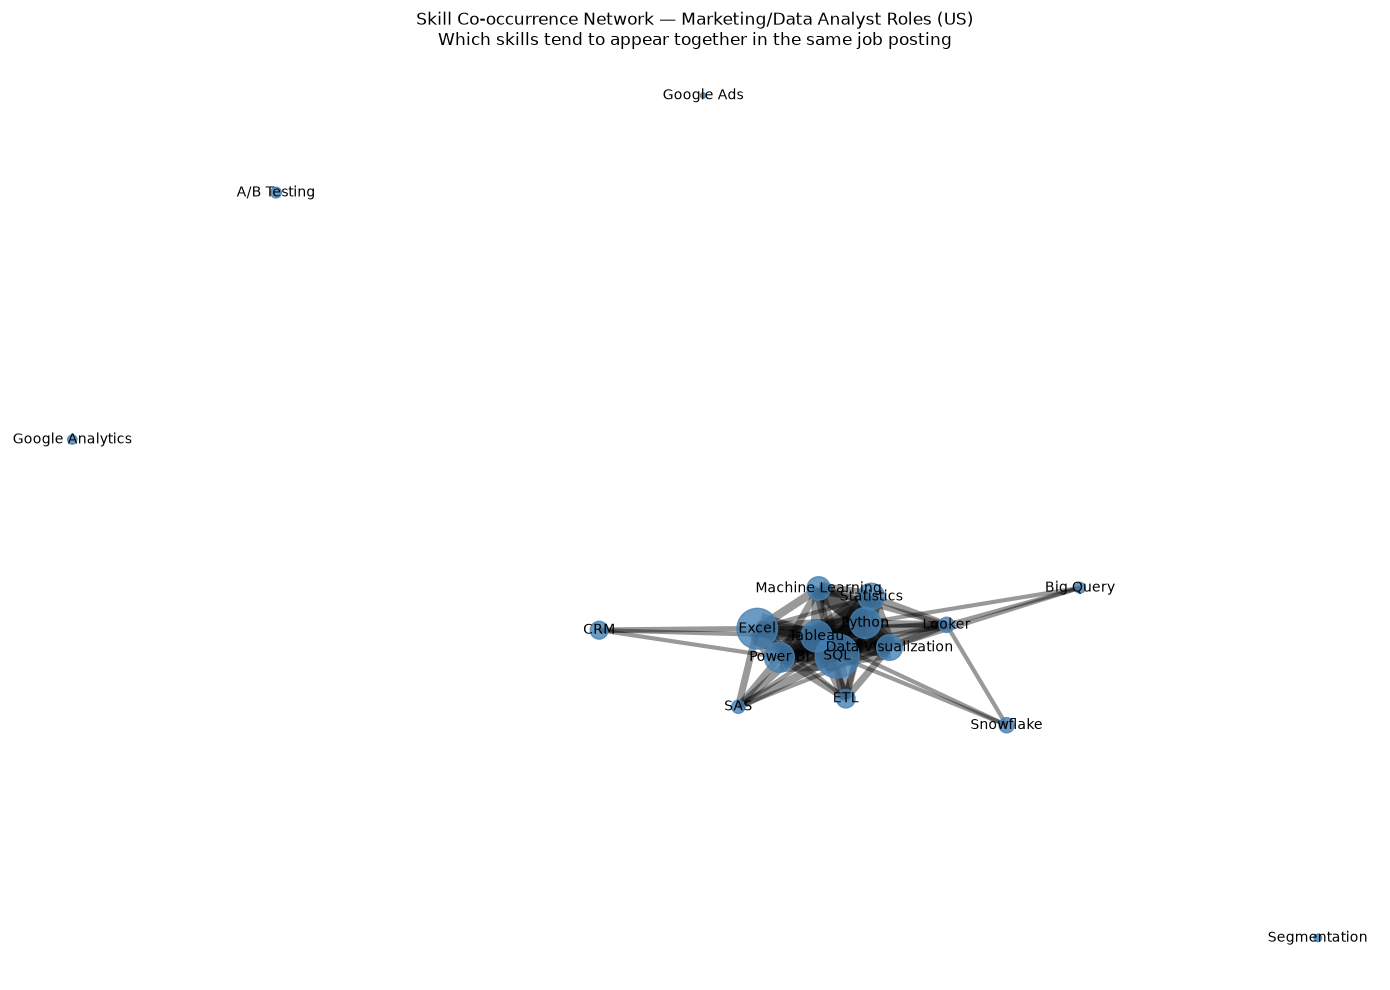

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.7, seed=42)

node_sizes = [G.nodes[n]["weight"] * 15 for n in G.nodes]
edge_widths = [G[u][v]["weight"] for u, v in G.edges]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="steelblue", alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

ax.set_title("Skill Co-occurrence Network — Marketing/Data Analyst Roles (US)\nWhich skills tend to appear together in the same job posting")
ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/skill_network.png", dpi=150)
plt.show()

interactive version (this is the one to actually share)

In [49]:
# Remove nodes with no edges — they don't belong in a co-occurrence visualization
isolated_nodes = list(nx.isolates(G))
print(f"Removing {len(isolated_nodes)} isolated nodes: {isolated_nodes}")
G_connected = G.copy()
G_connected.remove_nodes_from(isolated_nodes)

print(f"Connected network: {G_connected.number_of_nodes()} skills, {G_connected.number_of_edges()} connections")

Removing 4 isolated nodes: ['Google Analytics', 'A/B Testing', 'Segmentation', 'Google Ads']
Connected network: 14 skills, 59 connections


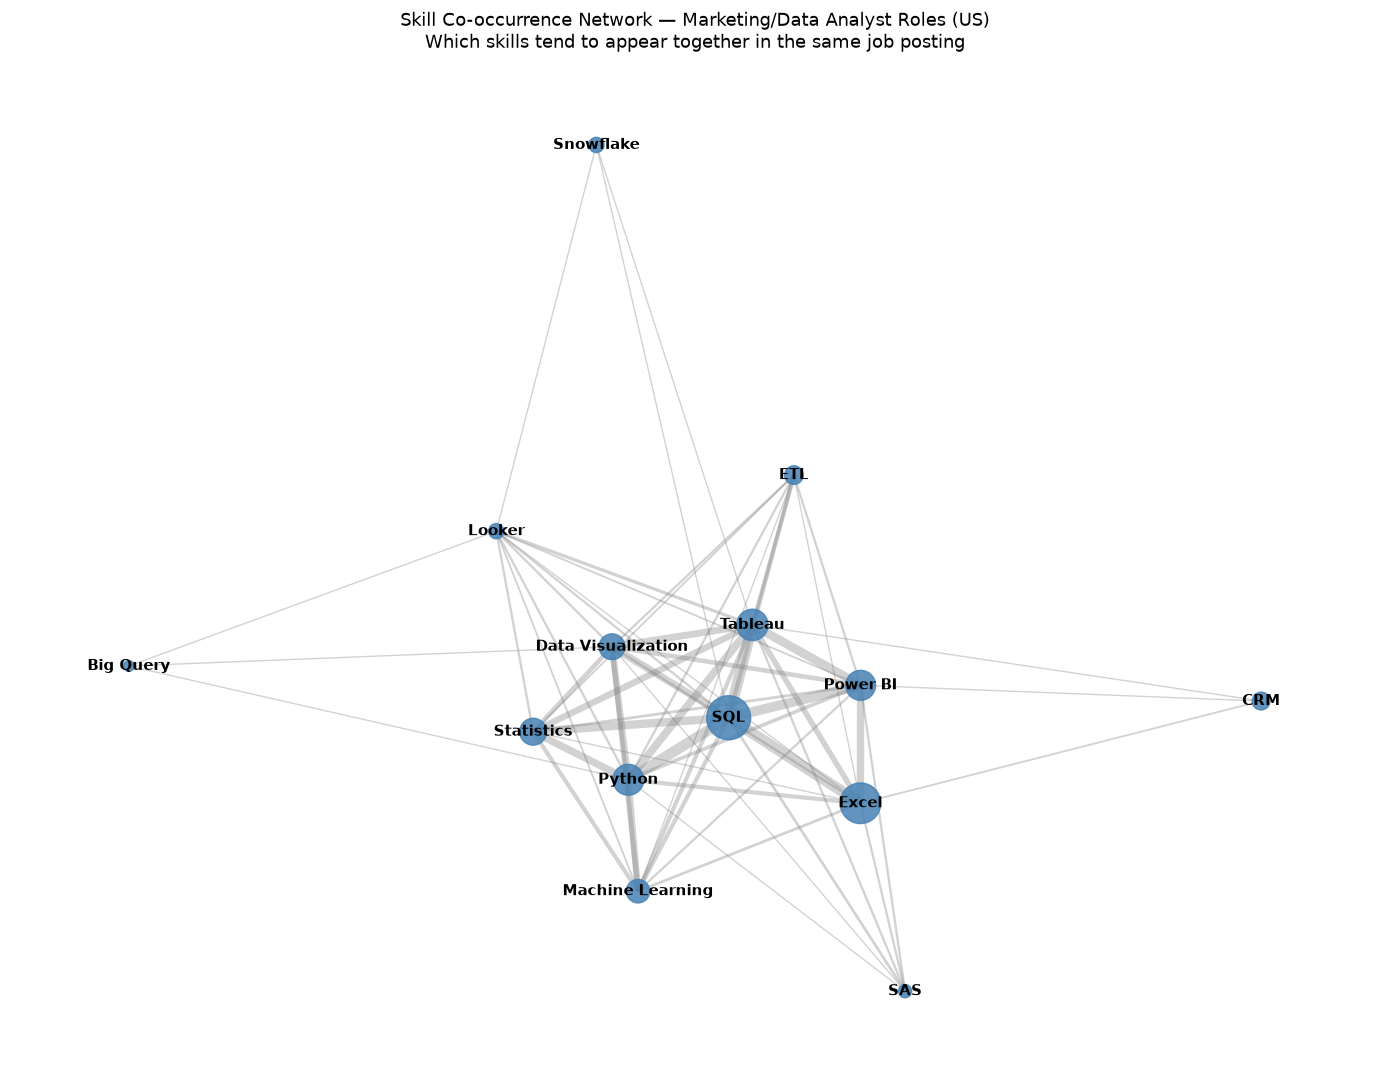

In [50]:
fig, ax = plt.subplots(figsize=(14, 11))
pos = nx.spring_layout(G_connected, k=1.2, seed=42, iterations=100)

node_sizes = [G_connected.nodes[n]["weight"] * 15 for n in G_connected.nodes]
edge_widths = [G_connected[u][v]["weight"] / 3 for u, v in G_connected.edges]

nx.draw_networkx_nodes(G_connected, pos, node_size=node_sizes, node_color="steelblue", alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_connected, pos, width=edge_widths, alpha=0.35, edge_color="gray", ax=ax)
nx.draw_networkx_labels(G_connected, pos, font_size=11, font_weight="bold", ax=ax)

ax.set_title("Skill Co-occurrence Network — Marketing/Data Analyst Roles (US)\nWhich skills tend to appear together in the same job posting", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/skill_network.png", dpi=150)
plt.show()

In [51]:
from pyvis.network import Network

net = Network(height="700px", width="100%", bgcolor="#ffffff", font_color="black")
for node in G_connected.nodes:
    net.add_node(node, label=node, value=G_connected.nodes[node]["weight"])
for u, v in G_connected.edges:
    net.add_edge(u, v, value=G_connected[u][v]["weight"])

net.save_graph("../outputs/skill_network_interactive.html")

In [52]:
skill_demand_by_market.to_csv("../data/processed/skill_demand_by_market.csv", index=False)